In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/kaggle/input/datasets/janiobachmann/bank-marketing-dataset/bank.csv")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.shape

(11162, 17)

In [5]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [6]:
df['poutcome'].unique()

array(['unknown', 'other', 'failure', 'success'], dtype=object)

In [7]:
df['deposit'].unique()

array(['yes', 'no'], dtype=object)

In [8]:
df['default'].unique()

array(['no', 'yes'], dtype=object)

In [9]:
mode_edu = df['education'].mode()[0]
df['education'] = df['education'].fillna(mode_edu)

In [10]:
mode_con = df['contact'].mode()[0]
df['contact'] = df['contact'].fillna(mode_con)

In [11]:
df['loan'] = df['loan'].map({'yes':1, 'no':0})

In [12]:
df['housing'] = df['housing'].map({'yes':1, 'no':0})

In [13]:
df['default'] = df['default'].map({'yes':1, 'no':0})

In [14]:
df['deposit'] = df['deposit'].map({'yes':1, 'no':0})

In [15]:
df['contact'].unique()

array(['unknown', 'cellular', 'telephone'], dtype=object)

In [16]:
df = df.replace('unknown', np.nan)
df = df.dropna(subset=['contact','job'])

In [17]:
df.drop('poutcome', axis=1, inplace=True)
df.drop('duration', axis=1, inplace=True)

In [18]:
X = df.drop('deposit', axis = 1)
y = df['deposit']

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.tree import DecisionTreeClassifier

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [22]:
num_cols = ['age','balance','day','campaign','pdays']

imputer = SimpleImputer(strategy='median')

X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

In [23]:
month_order = [['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']]

ordinal_encoder = OrdinalEncoder(categories=month_order)

X_train['month'] = ordinal_encoder.fit_transform(X_train[['month']])
X_test['month'] = ordinal_encoder.transform(X_test[['month']])

In [24]:
scaler = StandardScaler()

cols_to_scale = ['age', 'balance', 'day', 'campaign', 'pdays']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [25]:
cat_cols = ['job','marital','contact','education']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

X_train = X_train.drop(cat_cols, axis=1)
X_test = X_test.drop(cat_cols, axis=1)

In [26]:
scale_cols = ['age','balance','day','campaign','pdays']

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [27]:
X_train_final = np.concatenate([X_train.values, X_train_cat], axis=1)
X_test_final = np.concatenate([X_test.values, X_test_cat], axis=1)

In [28]:
imputer = SimpleImputer(strategy='median')

X_train_final = imputer.fit_transform(X_train_final)
X_test_final = imputer.transform(X_test_final)

Logisitic Regression Model

In [29]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_final, y_train)

LogisticRegression(max_iter=1000)

In [30]:
pred = log_model.predict(X_test_final)

In [31]:
print(accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))
roc_auc = roc_auc_score(y_test, pred)
print("\nROC-AUC Score:", roc_auc)

0.6449771689497716
[[456 356]
 [266 674]]
              precision    recall  f1-score   support

           0       0.63      0.56      0.59       812
           1       0.65      0.72      0.68       940

    accuracy                           0.64      1752
   macro avg       0.64      0.64      0.64      1752
weighted avg       0.64      0.64      0.64      1752


ROC-AUC Score: 0.6392988156377738


Decision Tree Model

In [32]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train_final, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [33]:
y_pred = dt_model.predict(X_test_final)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6575342465753424
[[663 149]
 [451 489]]
              precision    recall  f1-score   support

           0       0.60      0.82      0.69       812
           1       0.77      0.52      0.62       940

    accuracy                           0.66      1752
   macro avg       0.68      0.67      0.65      1752
weighted avg       0.69      0.66      0.65      1752



In [35]:
log_pred = log_model.predict(X_test_final)
dt_pred = dt_model.predict(X_test_final)

log_acc = accuracy_score(y_test, log_pred)
dt_acc = accuracy_score(y_test, dt_pred)

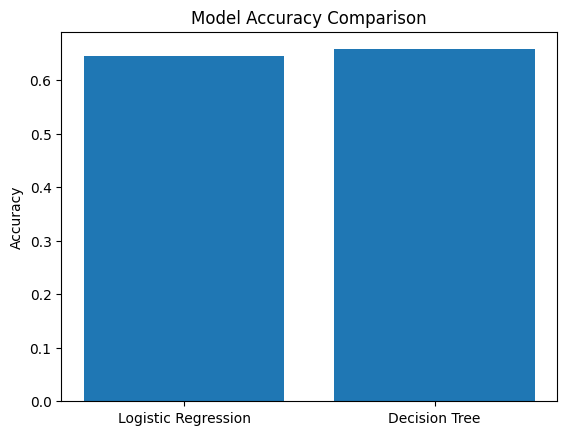

In [36]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree']
accuracies = [log_acc, dt_acc]

plt.figure()
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

In [37]:
log_prob = log_model.predict_proba(X_test_final)[:,1]
dt_prob = dt_model.predict_proba(X_test_final)[:,1]

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

log_auc = roc_auc_score(y_test, log_prob)
dt_auc = roc_auc_score(y_test, dt_prob)

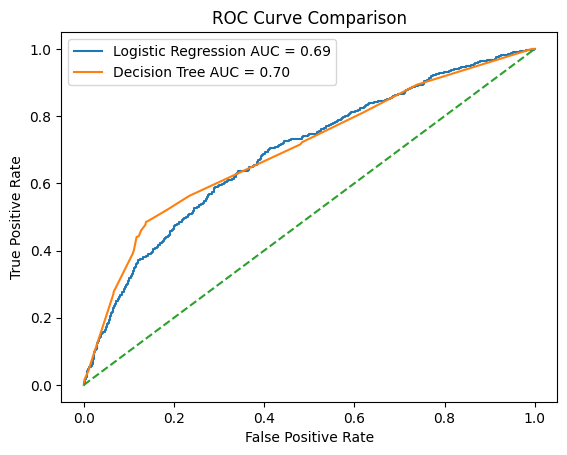

In [38]:
plt.figure()

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression AUC = {log_auc:.2f}")
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree AUC = {dt_auc:.2f}")

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [39]:
log_prob = log_model.predict_proba(X_test_final)[:,1]
dt_prob = dt_model.predict_proba(X_test_final)[:,1]

In [40]:
log_precision, log_recall, _ = precision_recall_curve(y_test, log_prob)
dt_precision, dt_recall, _ = precision_recall_curve(y_test, dt_prob)

log_ap = average_precision_score(y_test, log_prob)
dt_ap = average_precision_score(y_test, dt_prob)

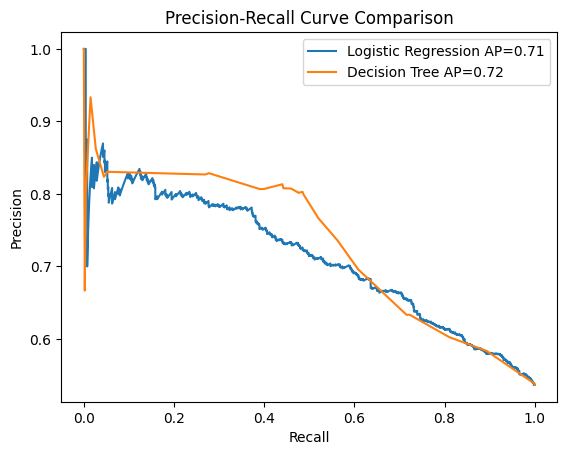

In [41]:
plt.figure()

plt.plot(log_recall, log_precision, label=f"Logistic Regression AP={log_ap:.2f}")
plt.plot(dt_recall, dt_precision, label=f"Decision Tree AP={dt_ap:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.show()